In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

In [4]:
df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)
df["type"] = "top_track"
df

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
...,...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900,top_track
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652,top_track
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289,top_track


## Setup the dataset

In [5]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_52421/1256999401.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
...,...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900,top_track
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652,top_track
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289,top_track


In [6]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
5,Science,Matthew Valencia,0.241306,0.487671,0.013941,0.035955,top_track
...,...,...,...,...,...,...,...
49990,Protect,Michael Ramirez Jr.,0.483449,0.092080,0.302563,0.360458,top_track
49991,Support threat,Michael Ramirez Jr.,0.026095,0.291989,0.091185,0.303034,top_track
49993,Describe,Michael Ramirez Jr.,0.036705,0.299850,0.105375,0.256012,top_track
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track


In [7]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_52421/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_52421/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 100 users, 2665 items and 12301 interactions, so the sparsity is 4.62%.


In [9]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
Cory Hernandez         252
Keith Hodge            245
Sandra Richardson      198
Brian Bowman           188
Michael Ramirez Jr.    185
                      ... 
Steven White            84
Melinda Bradley         82
Mark Wilson             81
Robert Santos           80
Mitchell Jensen         79
Name: count, Length: 100, dtype: int64

,count,old_index
username,,
Mr. John Vazquez,94,Mr. John Vazquez
Hannah Martinez,105,Hannah Martinez
Paula Petersen,98,Paula Petersen
Ann Reed,112,Ann Reed
Russell Schmidt,112,Russell Schmidt
...,...,...
Patrick Simon,102,Patrick Simon
Zachary Sparks,97,Zachary Sparks
Carmen Howard,163,Carmen Howard


In [10]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
Mr. John Vazquez,94,Mr. John Vazquez
Hannah Martinez,105,Hannah Martinez
Paula Petersen,98,Paula Petersen
Ann Reed,112,Ann Reed
Russell Schmidt,112,Russell Schmidt
...,...,...
Patrick Simon,102,Patrick Simon
Zachary Sparks,97,Zachary Sparks
Carmen Howard,163,Carmen Howard


Train data:


,count,old_index
username,,
Mr. John Vazquez,94,Mr. John Vazquez
Hannah Martinez,105,Hannah Martinez
Paula Petersen,98,Paula Petersen
Ann Reed,112,Ann Reed
Russell Schmidt,112,Russell Schmidt
...,...,...
Michael Evans,91,Michael Evans
Richard Turner,104,Richard Turner
Mitchell Jensen,79,Mitchell Jensen


Validation data:


,count,old_index
username,,
Stephanie Parker,109,Stephanie Parker
Karen Jones,99,Karen Jones
Jason Morris,111,Jason Morris
Micheal Collier,99,Micheal Collier
Timothy Webb,102,Timothy Webb
Mark Wilson,81,Mark Wilson
Patricia Davis,95,Patricia Davis
Jorge Jones,119,Jorge Jones
Joyce Soto,103,Joyce Soto


Test data:


,count,old_index
username,,
Jessica Lewis,101,Jessica Lewis
Matthew Murphy,93,Matthew Murphy
Michael Brown,125,Michael Brown
Erin Smith,141,Erin Smith
Keith Hodge,245,Keith Hodge
Hayden Moody,105,Hayden Moody
Shane Dennis,150,Shane Dennis
Sandra Richardson,198,Sandra Richardson
Dillon Davis,149,Dillon Davis


Train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
5,Science,Matthew Valencia,0.241306,0.487671,0.013941,0.035955,top_track
...,...,...,...,...,...,...,...
49990,Protect,Michael Ramirez Jr.,0.483449,0.092080,0.302563,0.360458,top_track
49991,Support threat,Michael Ramirez Jr.,0.026095,0.291989,0.091185,0.303034,top_track
49993,Describe,Michael Ramirez Jr.,0.036705,0.299850,0.105375,0.256012,top_track
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track


Validation train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
5008,Newspaper,Amanda Hernandez,0.220751,0.219137,0.442327,0.539202,top_track
5011,Approach,Amanda Hernandez,0.048629,0.537922,0.062162,0.452637,top_track
5032,Practice,Amanda Hernandez,0.304690,0.459671,0.528538,0.473717,top_track
5044,Difficult,Amanda Hernandez,0.322420,0.025336,0.082890,0.371543,top_track
5053,Challenge,Amanda Hernandez,0.021459,0.144234,0.365299,0.336810,top_track
...,...,...,...,...,...,...,...
34894,Window,Wendy Riggs DDS,0.052677,0.045293,0.157874,0.060476,top_track
34951,Customer,Wendy Riggs DDS,0.286606,0.038420,0.401132,0.141005,top_track
34973,Officer,Wendy Riggs DDS,0.229636,0.195792,0.013710,0.088955,top_track
34983,Attention,Wendy Riggs DDS,0.084604,0.387017,0.098333,0.364704,top_track


Validation test data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
5000,Professional,Amanda Hernandez,0.439894,0.649639,0.335586,0.089389,top_track
5013,Democratic,Amanda Hernandez,0.117168,0.385577,0.164448,0.345044,top_track
5015,Generation,Amanda Hernandez,0.409983,0.122690,0.192258,0.006360,top_track
5025,Culture,Amanda Hernandez,0.169360,0.302754,0.118027,0.061868,top_track
5038,Quite,Amanda Hernandez,0.197924,0.093754,0.079677,0.270349,top_track
...,...,...,...,...,...,...,...
34925,Herself,Wendy Riggs DDS,0.399229,0.030463,0.332645,0.132040,top_track
34926,Thing,Wendy Riggs DDS,0.032057,0.331758,0.315429,0.188118,top_track
34944,Close,Wendy Riggs DDS,0.356348,0.023607,0.086919,0.069300,top_track
34977,Character,Wendy Riggs DDS,0.094072,0.249881,0.371736,0.228545,top_track


Test train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
25003,Discussion,Anthony Schwartz,0.356463,0.585346,0.135598,0.291504,top_track
25008,Throughout,Anthony Schwartz,0.391797,0.193540,0.187139,0.107142,top_track
25018,Management,Anthony Schwartz,0.397581,0.107389,0.293166,0.115369,top_track
25035,Usually,Anthony Schwartz,0.466965,0.088317,0.253265,0.728098,top_track
25044,Tell,Anthony Schwartz,0.462908,0.144728,0.114355,0.400752,top_track
...,...,...,...,...,...,...,...
42421,Support,Zachary Sparks,0.365460,0.122277,0.174990,0.008303,top_track
42425,Project,Zachary Sparks,0.159237,0.297133,0.106632,0.097148,top_track
42474,Authority,Zachary Sparks,0.367407,0.216970,0.113760,0.188085,top_track
42480,Matter,Zachary Sparks,0.658043,0.020965,0.044565,0.655692,top_track


Test test data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
25004,Marriage,Anthony Schwartz,0.320403,0.038026,0.191935,0.094295,top_track
25010,Word,Anthony Schwartz,0.482019,0.193703,0.163673,0.175318,top_track
25013,Forget,Anthony Schwartz,0.406288,0.402971,0.114402,0.157160,top_track
25022,Analysis,Anthony Schwartz,0.016137,0.552981,0.427736,0.263326,top_track
25023,Approach,Anthony Schwartz,0.076666,0.088082,0.053174,0.002936,top_track
...,...,...,...,...,...,...,...
42455,Citizen,Zachary Sparks,0.327590,0.153620,0.134426,0.116815,top_track
42473,Building,Zachary Sparks,0.032478,0.589925,0.095236,0.101081,top_track
42484,Increase,Zachary Sparks,0.072703,0.431228,0.189193,0.055449,top_track
42488,Represent,Zachary Sparks,0.453667,0.469862,0.288613,0.388324,top_track


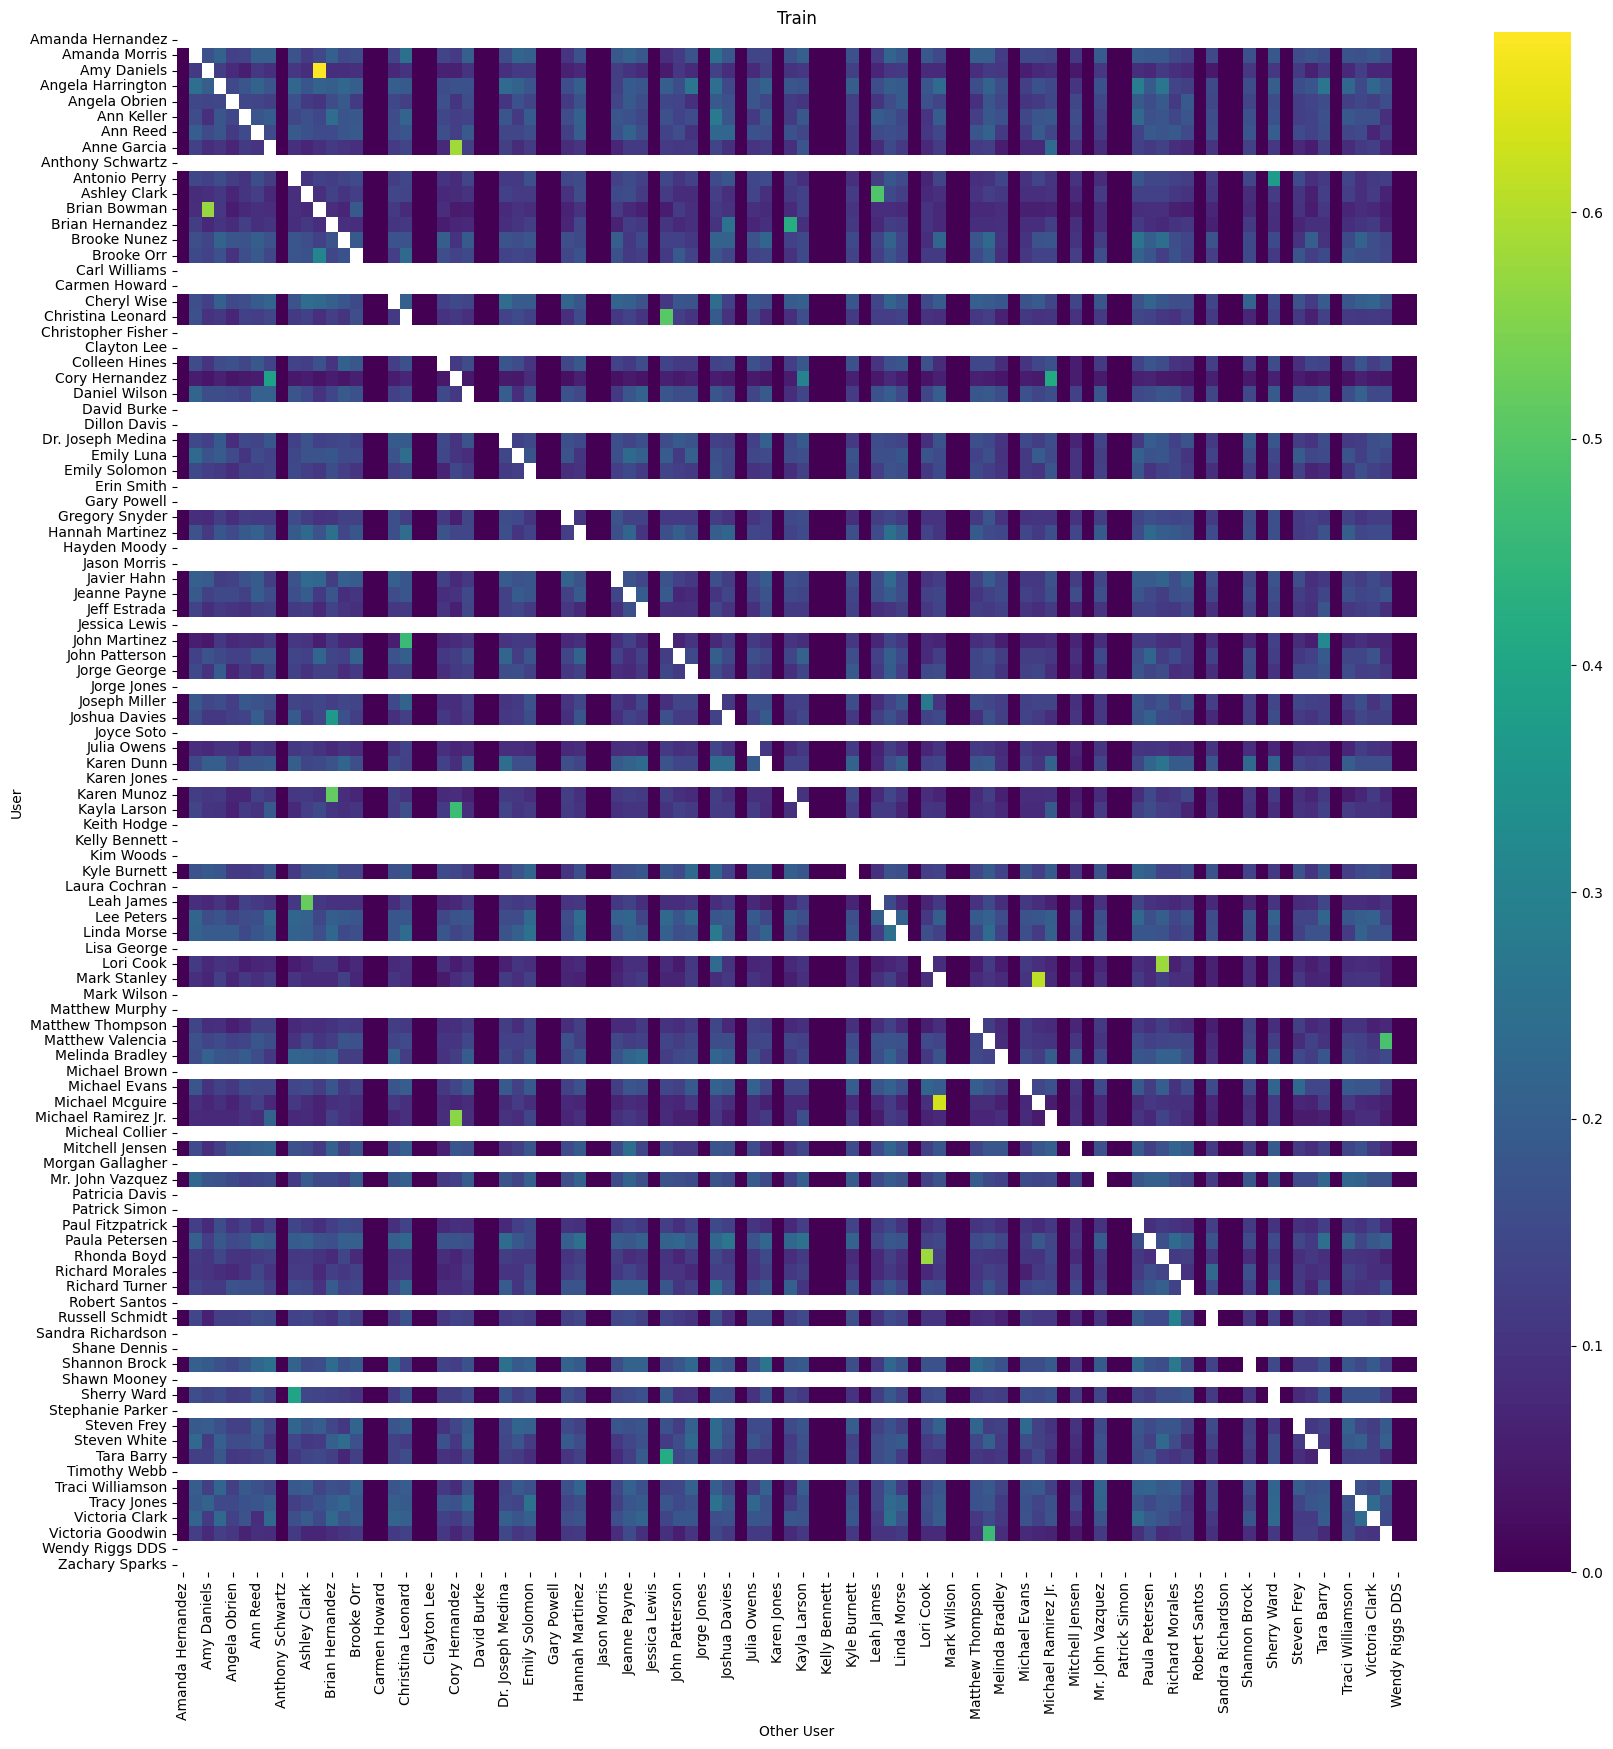

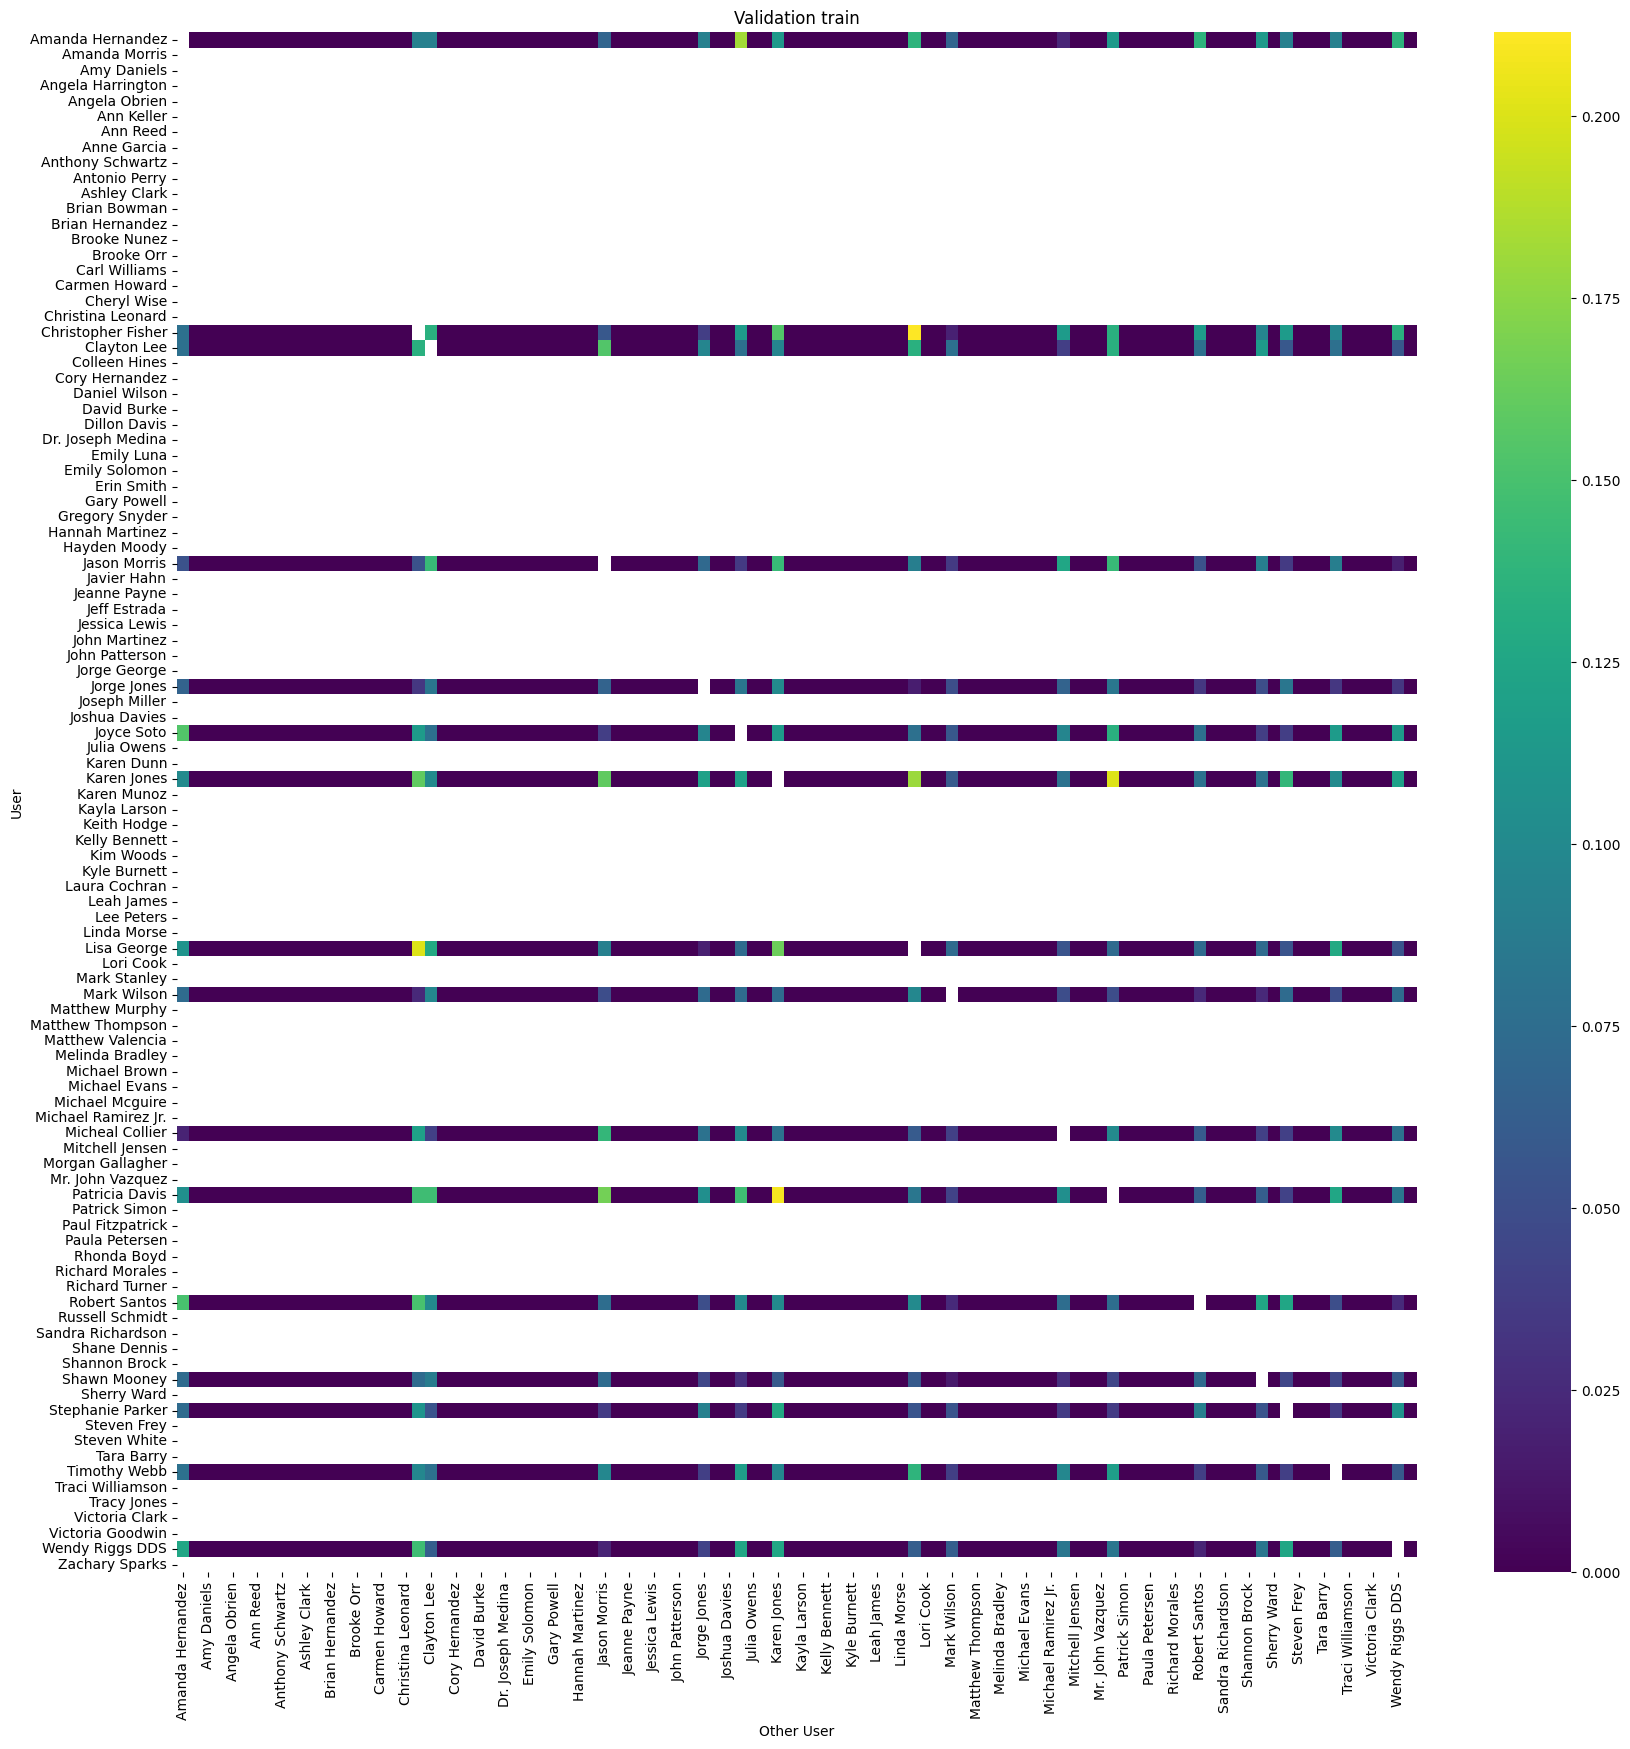

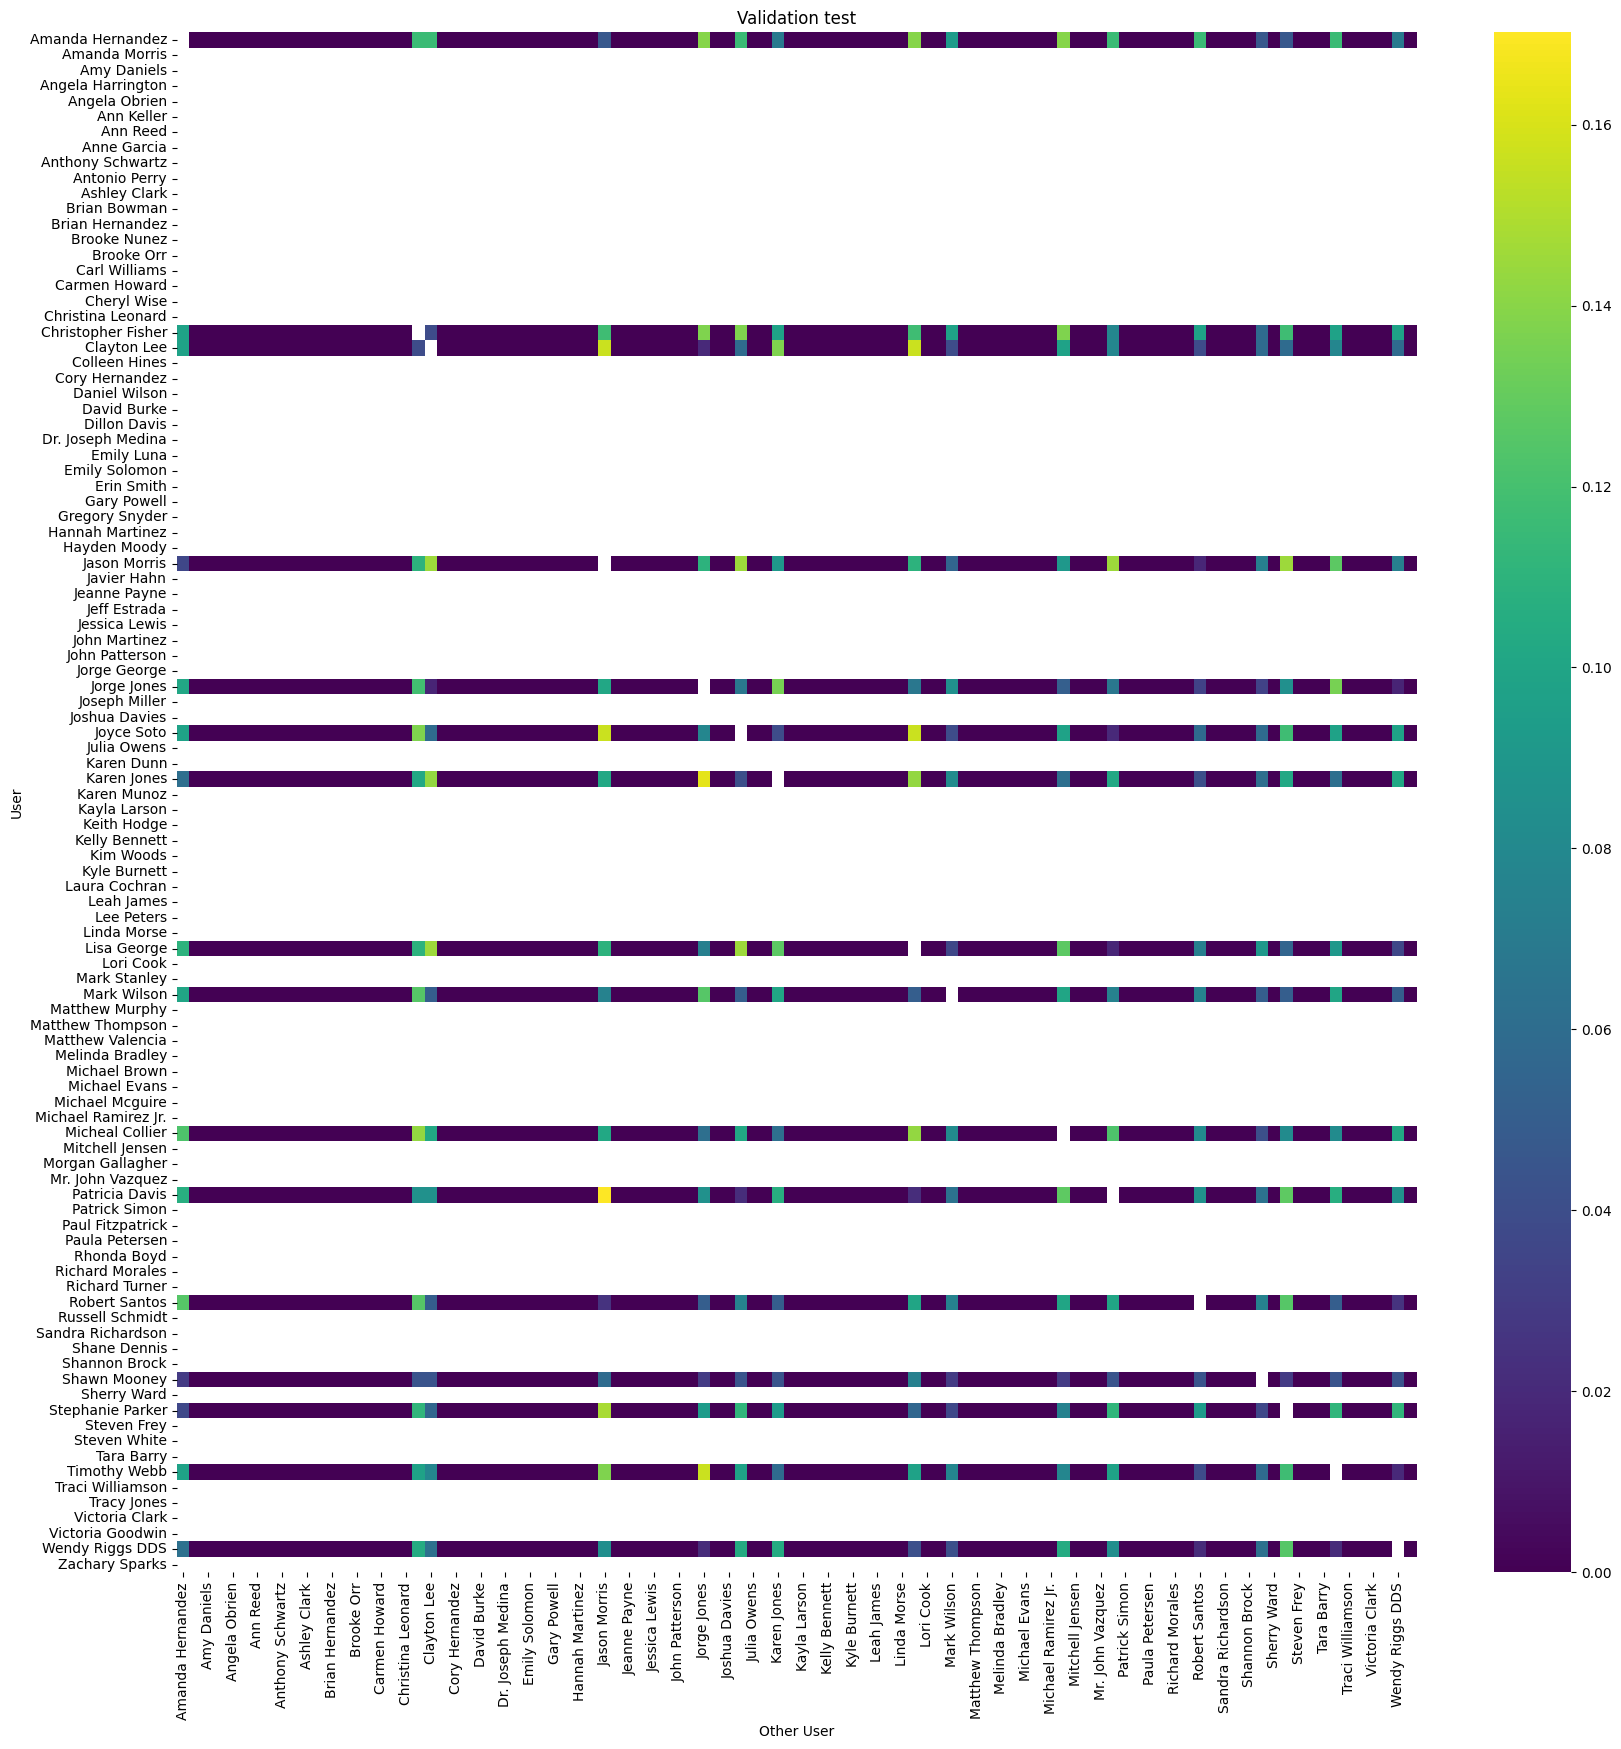

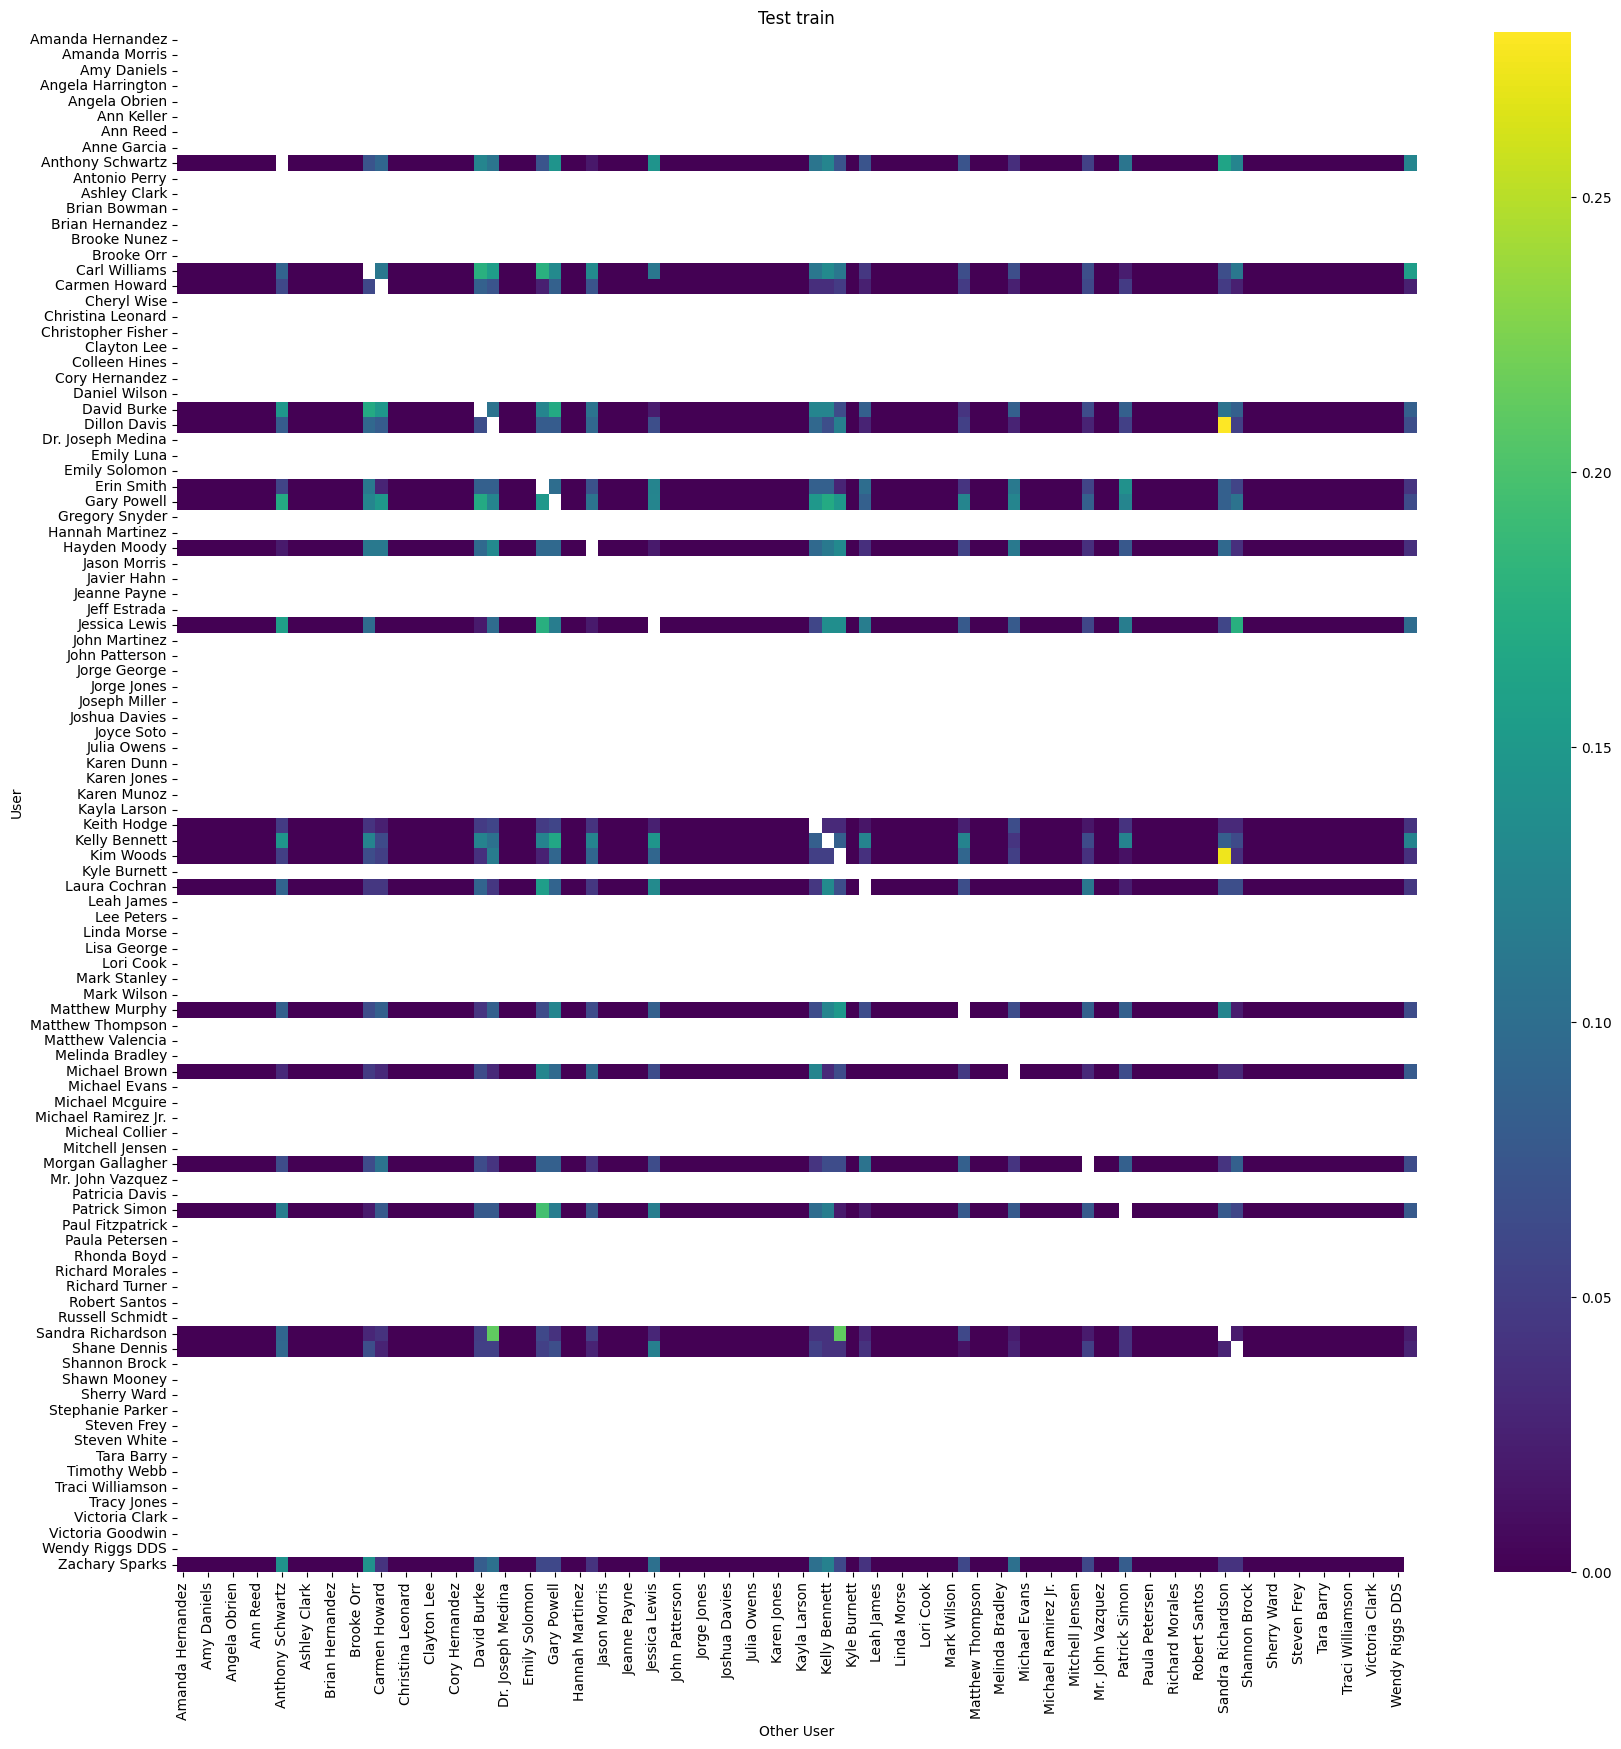

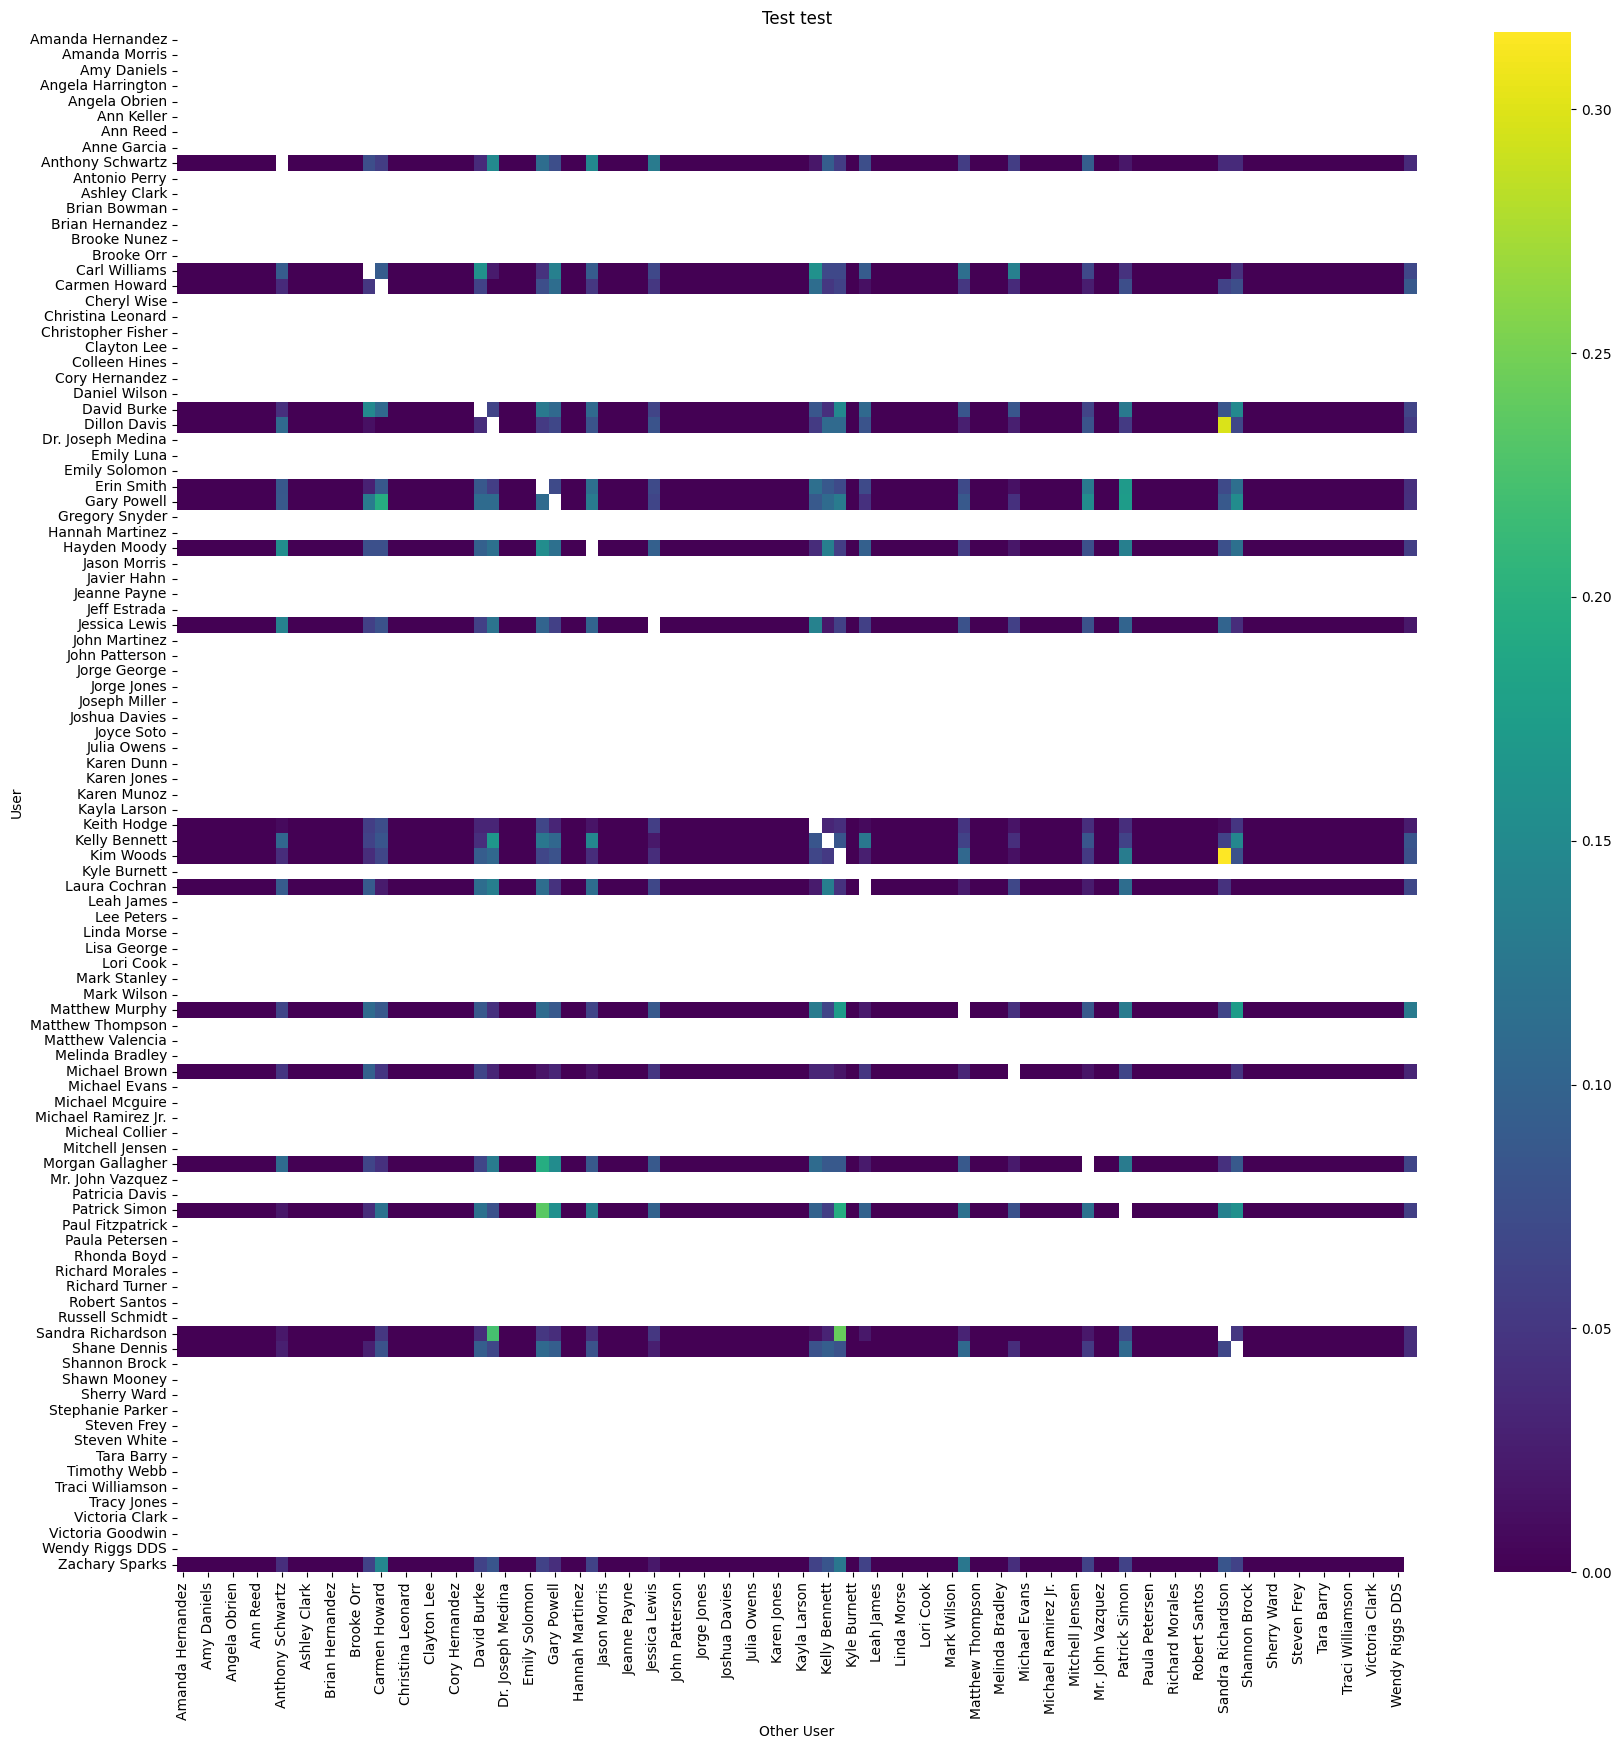

Alpha: 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Min max affinity: 0.0 83.74730682373047
Max affinity: 83.74730682373047


In [11]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [12]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([100, 2665])
Train dataset shape: torch.Size([100, 2665])
Validation train dataset shape: torch.Size([100, 2665])
Validation test dataset shape: torch.Size([100, 2665])
Test train dataset shape: torch.Size([100, 2665])
Test test dataset shape: torch.Size([100, 2665])


In [13]:
whole_matrix_dataset.R

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 46.2574],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  2.2241],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 20.8379],
        [ 0.0000, 26.5252,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 43.5428]],
       device='mps:0')

In [14]:
train_dataset = TensorDataset(train_matrix_dataset.R)
validation_dataset = TensorDataset(validation_train_matrix_dataset.R, validation_test_matrix_dataset.R)
test_dataset = TensorDataset(test_train_matrix_dataset.R, test_test_matrix_dataset.R)

# Define and train the MultiVAE model

In [15]:
p_dims = [200, 600, whole_matrix_dataset.R.shape[1]]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)
model

MultiVAE(
  (q_layers): ModuleList(
    (0): Linear(in_features=2665, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=400, bias=True)
  )
  (p_layers): ModuleList(
    (0): Linear(in_features=200, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=2665, bias=True)
  )
  (drop): Dropout(p=0.5, inplace=False)
)

In [16]:
batch_size = 32
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
(
    best_model,
    loss_history,
    validation_loss_history,
    ndcg_history,
    r20_history,
    r50_history,
    mpr_history,
) = model.train_model(
    optimizer,
    train_loader,
    num_epochs=30,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    validation_dataloader=validation_loader,
    log_interval=1,
)

Epoch: 0 	 Loss: 12637.745117 	 Val Loss: 1413.814087 	 NDCG_100: 0.019825 	 Recall_20: 0.109375 	 Recall_50: 0.081106 	 MPR: 0.369192
Epoch: 1 	 Loss: 12603.619141 	 Val Loss: 1409.907104 	 NDCG_100: 0.028307 	 Recall_20: 0.140625 	 Recall_50: 0.135439 	 MPR: 0.304013
Epoch: 2 	 Loss: 14609.862305 	 Val Loss: 1400.777344 	 NDCG_100: 0.030101 	 Recall_20: 0.128125 	 Recall_50: 0.158081 	 MPR: 0.287865
Epoch: 3 	 Loss: 13960.886719 	 Val Loss: 1380.323242 	 NDCG_100: 0.031058 	 Recall_20: 0.146875 	 Recall_50: 0.168387 	 MPR: 0.278882
Epoch: 4 	 Loss: 13534.345703 	 Val Loss: 1344.466919 	 NDCG_100: 0.032501 	 Recall_20: 0.159375 	 Recall_50: 0.189163 	 MPR: 0.269565
Epoch: 5 	 Loss: 11830.516602 	 Val Loss: 1325.081421 	 NDCG_100: 0.033824 	 Recall_20: 0.181250 	 Recall_50: 0.201339 	 MPR: 0.263165
Epoch: 6 	 Loss: 11850.134766 	 Val Loss: 1341.575806 	 NDCG_100: 0.032546 	 Recall_20: 0.181250 	 Recall_50: 0.212370 	 MPR: 0.260716
Epoch: 7 	 Loss: 12645.274414 	 Val Loss: 1350.066162 	

In [17]:
losses_df = pd.DataFrame([loss_history, validation_loss_history, ndcg_history, r20_history, r50_history, mpr_history]).T
losses_df.columns = ["loss", "validation_loss", "ndgk", "r20", "r50", "mpr"]

px.line(losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss").show()
px.line(losses_df, x=losses_df.index, y=["ndgk", "r20", "r50", "mpr"], title="Metrics").show()

In [18]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
total_loss, ndcg, recall_20, recall_50, mpr = best_model.evaluate_model(
    test_loader,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")
print(f"MPR: {mpr}")

Total loss: 2096.355849609375
NDCG_100: 0.036597322672605515
Recall_20: 0.20500001311302185
Recall_50: 0.1840747445821762
MPR: 0.2628658711910248


In [19]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()
user_names

['Amanda Hernandez',
 'Amanda Morris',
 'Amy Daniels',
 'Angela Harrington',
 'Angela Obrien',
 'Ann Keller',
 'Ann Reed',
 'Anne Garcia',
 'Anthony Schwartz',
 'Antonio Perry',
 'Ashley Clark',
 'Brian Bowman',
 'Brian Hernandez',
 'Brooke Nunez',
 'Brooke Orr',
 'Carl Williams',
 'Carmen Howard',
 'Cheryl Wise',
 'Christina Leonard',
 'Christopher Fisher',
 'Clayton Lee',
 'Colleen Hines',
 'Cory Hernandez',
 'Daniel Wilson',
 'David Burke',
 'Dillon Davis',
 'Dr. Joseph Medina',
 'Emily Luna',
 'Emily Solomon',
 'Erin Smith',
 'Gary Powell',
 'Gregory Snyder',
 'Hannah Martinez',
 'Hayden Moody',
 'Jason Morris',
 'Javier Hahn',
 'Jeanne Payne',
 'Jeff Estrada',
 'Jessica Lewis',
 'John Martinez',
 'John Patterson',
 'Jorge George',
 'Jorge Jones',
 'Joseph Miller',
 'Joshua Davies',
 'Joyce Soto',
 'Julia Owens',
 'Karen Dunn',
 'Karen Jones',
 'Karen Munoz',
 'Kayla Larson',
 'Keith Hodge',
 'Kelly Bennett',
 'Kim Woods',
 'Kyle Burnett',
 'Laura Cochran',
 'Leah James',
 'Lee Pet

In [20]:
z, mu, std, logvar = best_model.get_latent_representations(whole_matrix_dataset.R)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([100, 200])
torch.Size([100, 200])
torch.Size([100, 200])
torch.Size([100, 200])


In [21]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(10, 15)
dim2 = range(10, 15)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

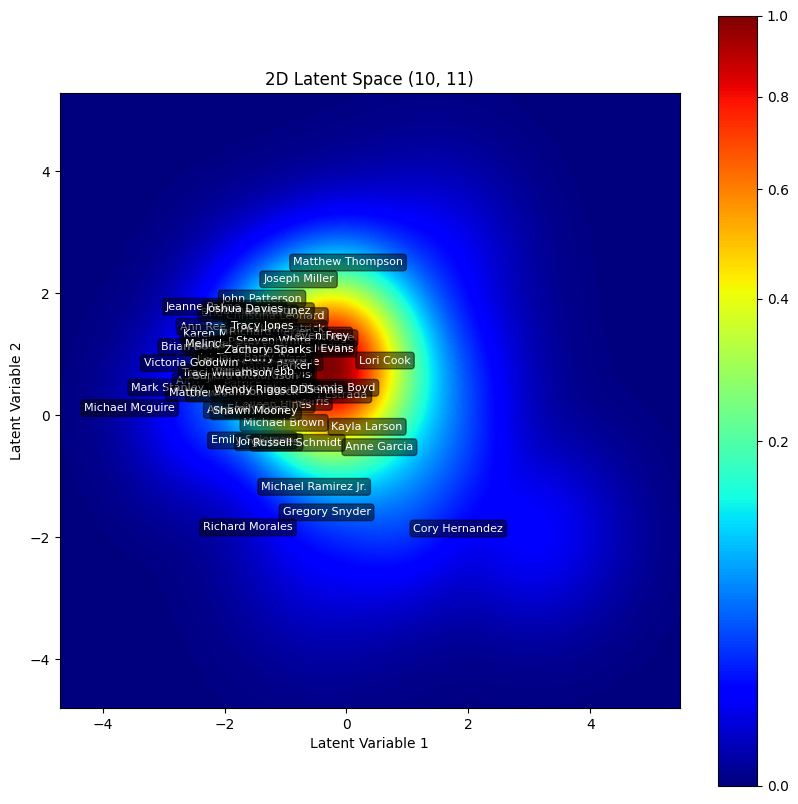

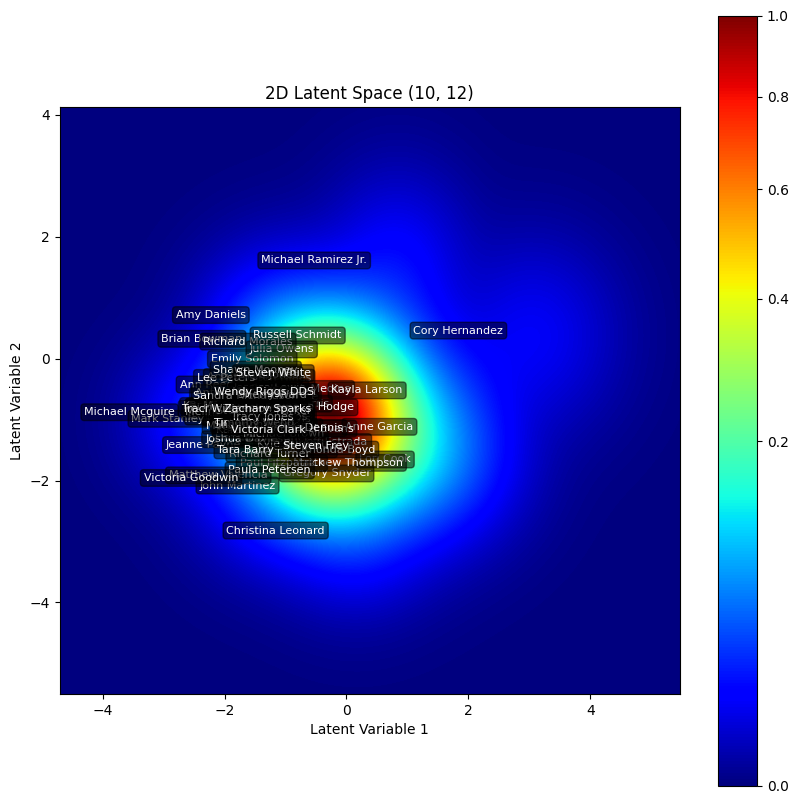

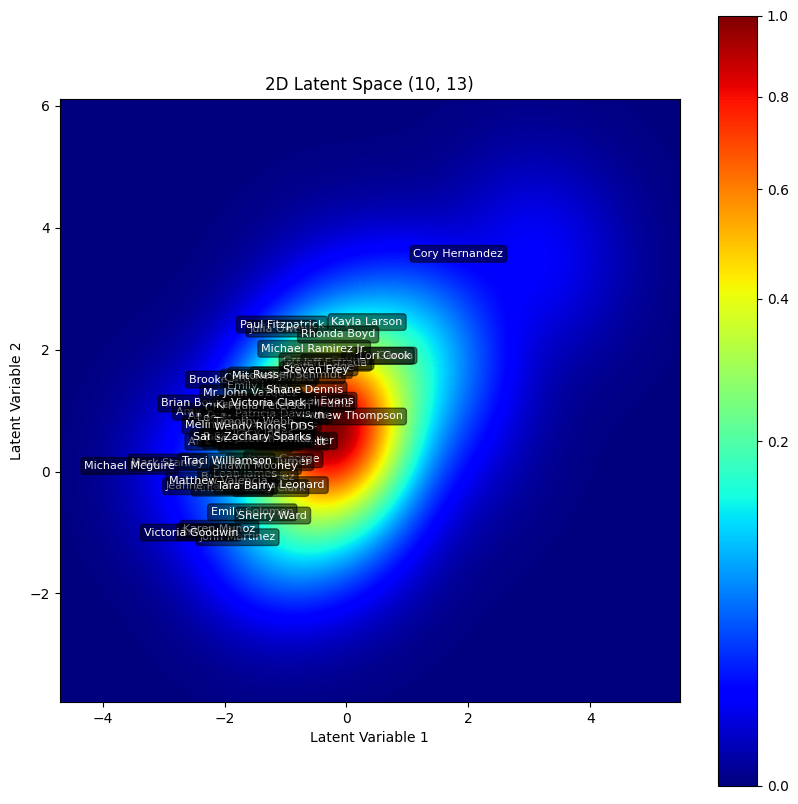

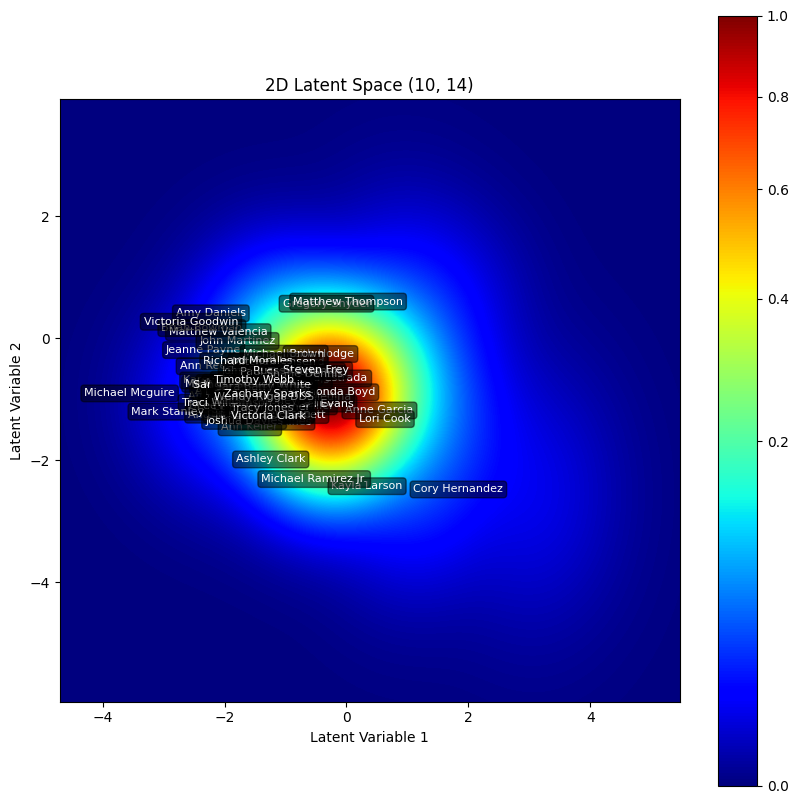

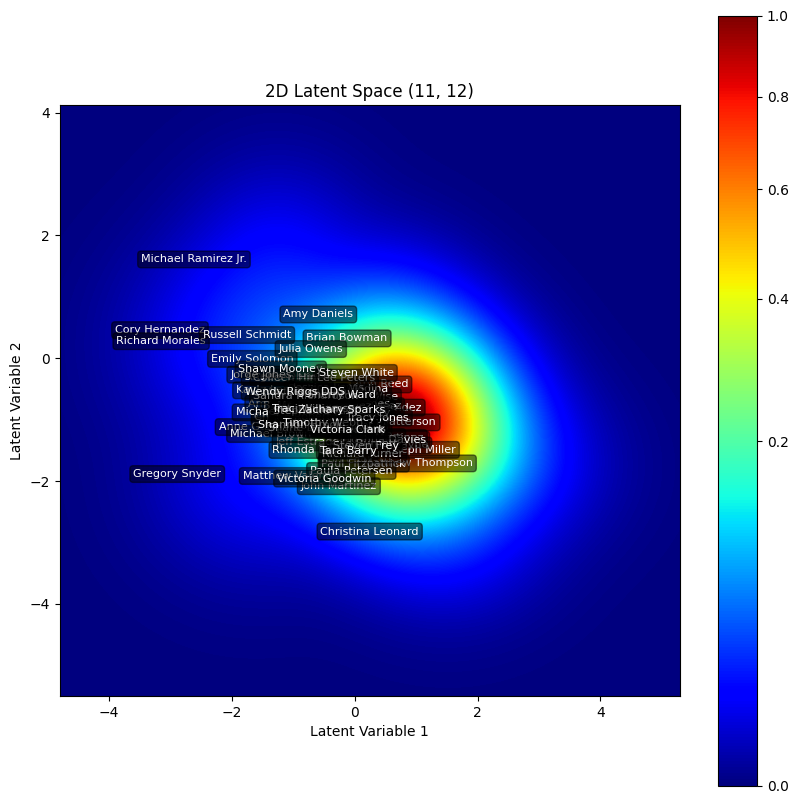

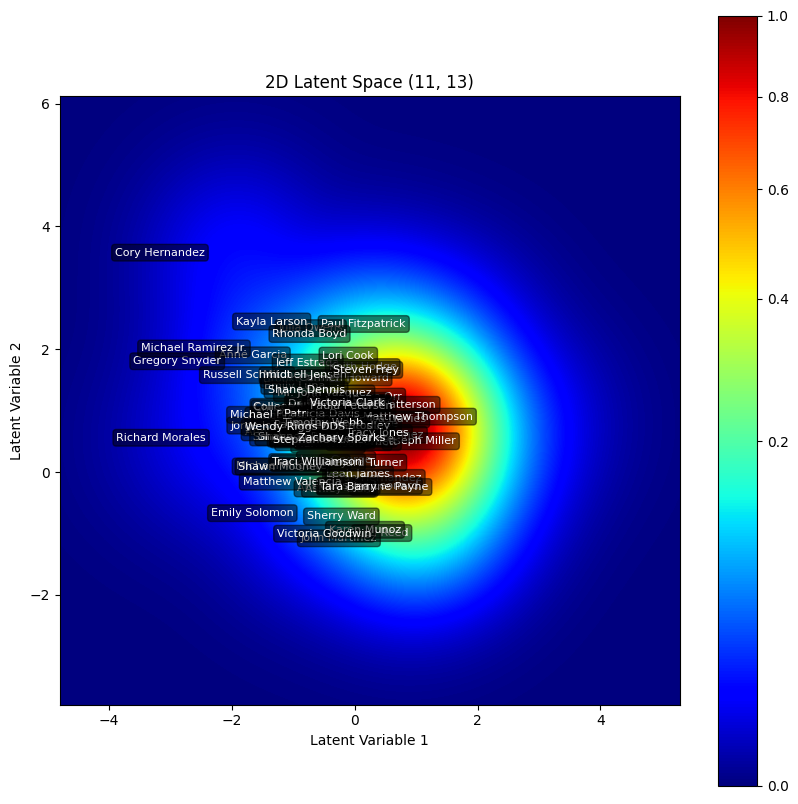

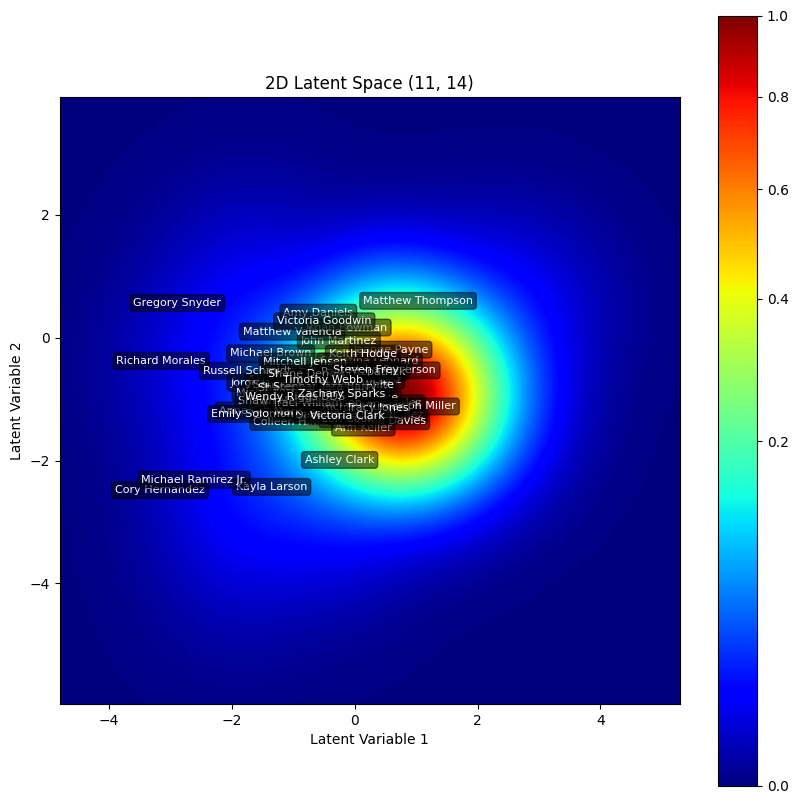

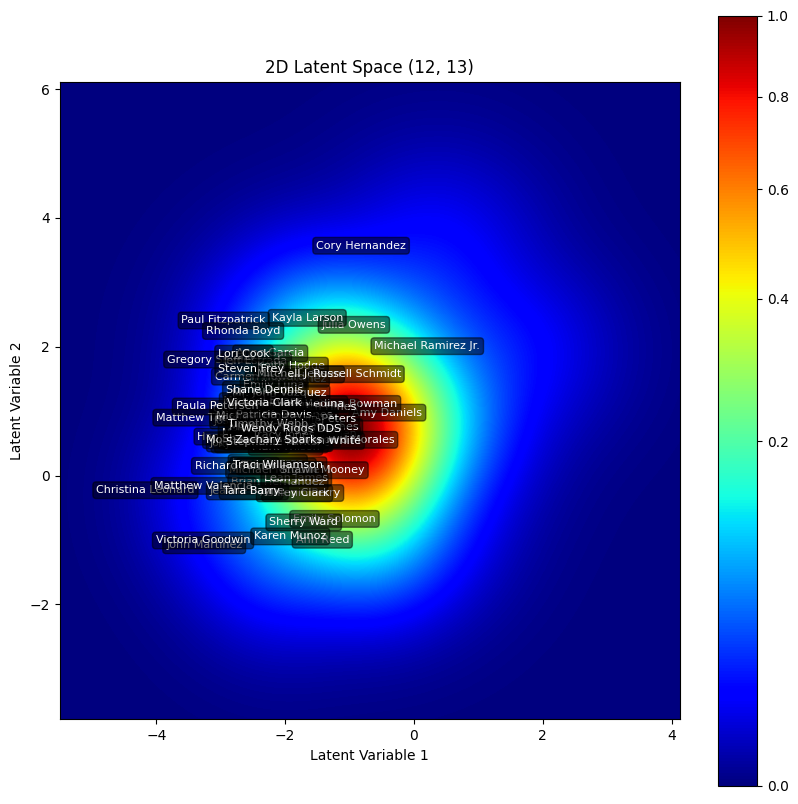

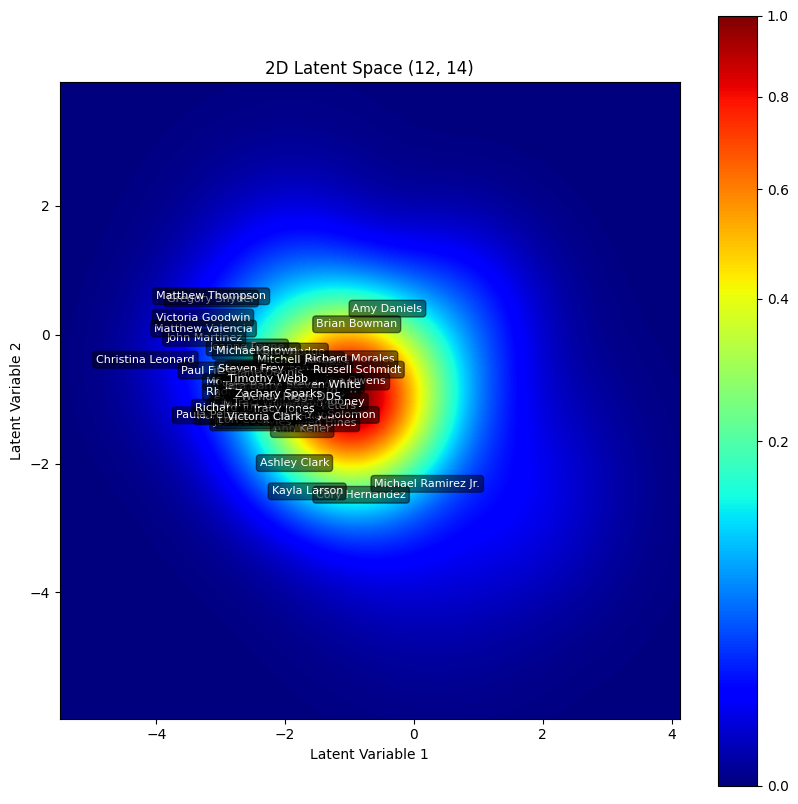

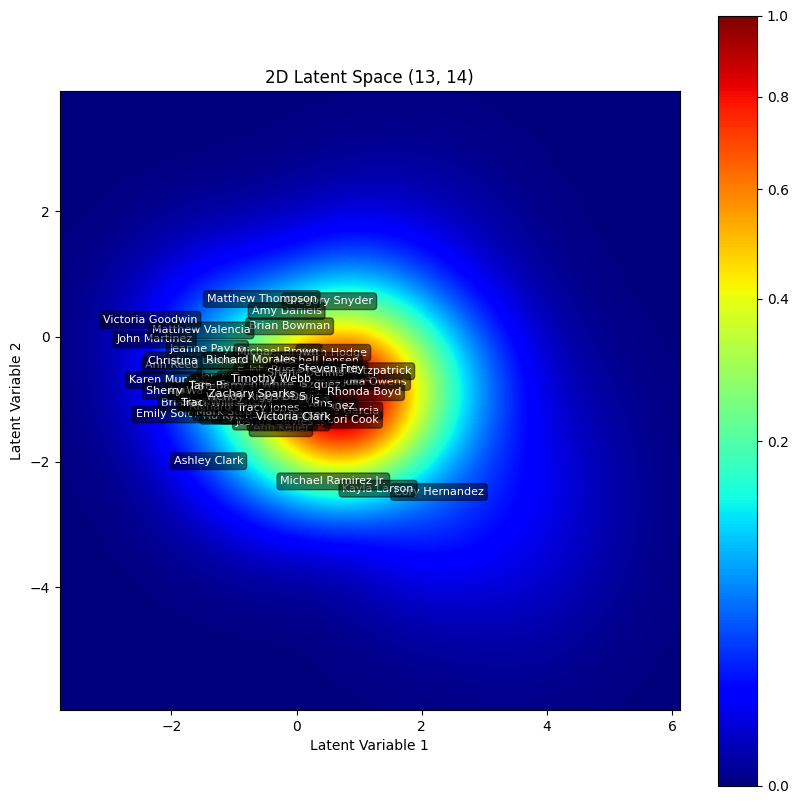

In [22]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            color_map="jet",
            # dpi=300,
            labels=user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

In [23]:
username = "owen"
user_id = whole_matrix_dataset.usernames_to_ids([username])[0]
username = whole_matrix_dataset.ids_to_usernames([user_id])[0]
print(f"User id: {user_id}, {username}")
user_seen = whole_matrix_dataset.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: -1, Zachary Sparks


(97,)

In [24]:
user_seen.cpu().numpy()

array([   9,   10,   19,   40,   92,  126,  133,  175,  196,  237,  253,
        270,  273,  319,  334,  355,  416,  433,  439,  465,  475,  477,
        480,  499,  501,  529,  546,  548,  578,  585,  628,  743,  744,
        746,  768,  769,  781,  784,  800,  991,  995, 1000, 1051, 1087,
       1104, 1116, 1136, 1207, 1218, 1273, 1283, 1296, 1298, 1299, 1325,
       1405, 1436, 1453, 1467, 1472, 1484, 1508, 1509, 1533, 1557, 1565,
       1671, 1672, 1677, 1706, 1707, 1713, 1766, 1816, 1826, 1830, 1842,
       1844, 1849, 1862, 1871, 1933, 1945, 1957, 1995, 2165, 2172, 2212,
       2230, 2268, 2450, 2457, 2472, 2474, 2549, 2607, 2664])

In [25]:
similar_users_ids = best_model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = whole_matrix_dataset.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['Stephanie Parker',
 'Micheal Collier',
 'Laura Cochran',
 'Hayden Moody',
 'Gary Powell',
 'Lisa George',
 'Dillon Davis',
 'Kelly Bennett',
 'Clayton Lee',
 'Christopher Fisher',
 'Morgan Gallagher',
 'Jessica Lewis',
 'Jason Morris',
 'Anthony Schwartz',
 'Mark Wilson',
 'Tracy Jones',
 'Kim Woods',
 'Patrick Simon',
 'Robert Santos',
 'Joyce Soto',
 'Karen Jones',
 'Timothy Webb',
 'Matthew Murphy',
 'Wendy Riggs DDS',
 'Karen Dunn',
 'Amanda Hernandez',
 'Carl Williams',
 'Patricia Davis',
 'David Burke',
 'Sandra Richardson',
 'Victoria Clark',
 'Linda Morse',
 'Erin Smith',
 'Ann Keller',
 'Paula Petersen',
 'Hannah Martinez',
 'Angela Harrington',
 'Dr. Joseph Medina',
 'Lee Peters',
 'Mr. John Vazquez',
 'Melinda Bradley',
 'Traci Williamson',
 'Kyle Burnett',
 'Colleen Hines',
 'Joseph Miller',
 'Brooke Nunez',
 'Daniel Wilson',
 'Michael Evans',
 'Javier Hahn',
 'Steven White',
 'Steven Frey',
 'John Patterson',
 'Richard Turner',
 'Michael Brown',
 'Cheryl Wise',
 'Joshua 

In [26]:
items_ids, predicted_scores = best_model.recommend(matrix=whole_matrix_dataset.R)
recommendation_df: pd.DataFrame = whole_matrix_dataset.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)

# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df["predicted_scores"] = pd.Series(predicted_scores.cpu().numpy()[user_id], index=items_ids.cpu().numpy()[user_id])

recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df = recommendation_df.drop_duplicates(subset=["username", "id"])
recommendation_df["seen"] = recommendation_df.index.isin(user_seen.cpu().numpy())
recommendation_df = recommendation_df[recommendation_df["seen"] == False]
recommendation_df = recommendation_df.drop_duplicates(subset=["id"])
recommendation_df = recommendation_df.sort_values(by="predicted_scores", ascending=False)

columns = spoti.PRETTY_PRINT_FEATURES
columns = list(recommendation_df.columns)
recommendation_df[["id", "predicted_scores", "seen"] + columns].head(100)

,id,predicted_scores,seen,id,username,danceability,duration_ms,instrumentalness,affinity,type,predicted_scores,seen
item_id,,,,,,,,,,,,
1574,Particular,3.045089,False,Particular,Brooke Orr,0.497367,0.361799,0.621234,0.081721,top_track,3.045089,False
1540,Organization,2.974244,False,Organization,Lori Cook,0.065895,0.236423,0.143410,0.453655,top_track,2.974244,False
2069,Somebody,2.939384,False,Somebody,Mark Stanley,0.172888,0.218073,0.055339,0.279997,top_track,2.939384,False
2072,Something,2.773214,False,Something,Joshua Davies,0.160994,0.181009,0.154691,0.041825,top_track,2.773214,False
1573,Participant,2.756185,False,Participant,Dillon Davis,0.087908,0.102330,0.604446,0.562943,top_track,2.756185,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2314,There,1.560803,False,There,Lee Peters,0.733587,0.053045,0.066365,0.835078,top_track,1.560803,False
2347,Thought,1.552821,False,Thought,Dillon Davis,0.594404,0.324564,0.002102,0.367584,top_track,1.552821,False
508,Continue,1.552197,False,Continue,Matthew Valencia,0.254210,0.642917,0.056805,0.455017,top_track,1.552197,False
